# **ML Models for an accurate GSE prediction**

## **Step 1. Import dataset**

In [1]:
import pandas as pd
import numpy as np


data = pd.read_csv('RFE_SolCbio3_descs_fps.csv') #import filtered descriptors
data.drop(columns=['smiles'], inplace=True) #remove unwanted columns

## **Step 2. Stratified sampling**
We want a balanced training and test set.

In [2]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split

# Create a new column 'output' by mapping 'dev' column
data['output'] = data['dev'].map({'NO': 0, 'YES': 1})

# Delete the original 'dev' column
data.drop(columns=['dev'], inplace=True)


X = data.drop('output', axis=1)
y = data['output']


sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in sss.split(X, y):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  X_train_val, X_val, y_train_val, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

  # Now you have stratified samples in X_train, X_test, y_train, and y_test

print(f'Training set (80%): {X_train.shape}')
print(f'Validation set (20% of TS): {X_val.shape}')
print(f'Test set (20%): {X_test.shape}')
print(f'Accurate predictions of GSE in test set: {100*round(y_test.value_counts()[0]/len(y_test),3)} %')
print(f'Accurate predictions of GSE in validation set: {100*round(y_val.value_counts()[0]/len(y_val),3)} %')
print(f'Accurate predictions of GSE in training set: {100*round(y_train.value_counts()[0]/len(y_train),3)} %')

Training set (80%): (2192, 75)
Validation set (20% of TS): (439, 75)
Test set (20%): (548, 75)
Accurate predictions of GSE in test set: 65.3 %
Accurate predictions of GSE in validation set: 65.4 %
Accurate predictions of GSE in training set: 65.4 %


## **Step 3. Random Forest**
Our first classification model will be a Random Forest.

1. Train te RF with the training set.
2. Optimize hyperparameters.
3. Predict the test set.
3. Report Accuracy, sensitivity, and specificity.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

# hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}


# Instantiate a RandomForestClassifier object
RF_rand = RandomForestClassifier(random_state=42)

# Instantiate a RandomizedSearchCV object
# n_iter controls the number of random combinations to try
random_search = RandomizedSearchCV(estimator=RF_rand, param_distributions=param_grid, n_iter=10, cv=10, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit the RandomizedSearchCV object to the training data
random_search.fit(X_train_val, y_train_val)

# Print the best hyperparameters
print("Best hyperparameters found by RandomizedSearchCV:")
print(random_search.best_params_)

Best hyperparameters found by RandomizedSearchCV:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30, 'criterion': 'entropy'}


In [4]:
RF_optimized = RandomForestClassifier(random_state=42, **random_search.best_params_) #train RF with tuned parameters
RF_optimized.fit(X_train_val, y_train_val)

y_val_proba = RF_optimized.predict_proba(X_val)[:, 1]

# Try many thresholds and pick the one that maximizes F1 (or Youden's J)
from sklearn.metrics import f1_score, roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
youden_j = tpr - fpr
best_threshold_youden = thresholds[np.argmax(youden_j)]

# Or maximize F1
f1_scores = []
for thresh in thresholds:
    y_pred_thresh = (y_val_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_thresh))
best_threshold_f1 = thresholds[np.argmax(f1_scores)]

print(f"Best threshold (Youden): {best_threshold_youden:.3f}")
print(f"Best threshold (F1):     {best_threshold_f1:.3f}")

Best threshold (Youden): 0.353
Best threshold (F1):     0.309


Optimized decision threshold: 0.3531904761904761
Optimized Model Accuracy: 0.7336
Optimized Model Sensitivity: 0.7486
Optimized Model Specificity: 0.7053


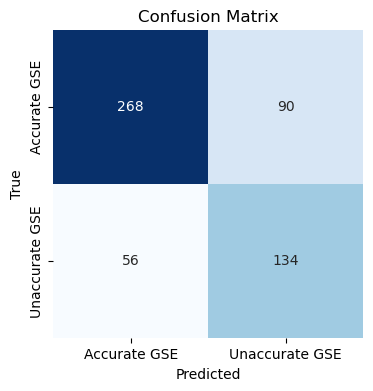

The accuracy of the Random Forest is 0.73


In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Predict on the test set
y_pred_RF_proba = RF_optimized.predict_proba(X_test)[:, 1]
y_pred_RF = (y_pred_RF_proba >= best_threshold_youden).astype(int)


# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_RF)

# Calculate accuracy, sensitivity, and specificity
tp, fn, fp, tn = cm.ravel()

rf_accuracy = (tp + tn) / (tp + tn + fp + fn)
rf_sensitivity = tp / (tp + fn)
rf_specificity = tn / (tn + fp)
rf_f1_score = (2*tp) / (2*tp+fp+fn)
rf_mcc = (tp*tn-fp*fn) / ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5

# Print the results
print(f'Optimized decision threshold: {best_threshold_youden}')
print(f'Optimized Model Accuracy: {rf_accuracy:.4f}')
print(f'Optimized Model Sensitivity: {rf_sensitivity:.4f}')
print(f'Optimized Model Specificity: {rf_specificity:.4f}')


# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Accurate GSE', 'Unaccurate GSE'], yticklabels=['Accurate GSE', 'Unaccurate GSE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

RF_ac = round((cm[0,0]+cm[1,1])/(cm[0,0]+cm[1,1]+cm[0,1]+cm[1,0]),2)

print(f'The accuracy of the Random Forest is {RF_ac}')

In [6]:
import joblib

# Create a dictionary to hold both the model and the threshold
model_and_threshold = {
    'model': RF_optimized,
    'threshold': best_threshold_youden
}

# Save the dictionary to a file
joblib.dump(model_and_threshold, 'RF_optimized_model_with_threshold.pkl')

print("RF_optimized model and best_threshold_youden saved as 'RF_optimized_model_with_threshold.pkl'")

RF_optimized model and best_threshold_youden saved as 'RF_optimized_model_with_threshold.pkl'


## **Step 4: Support Vector Machine**


1. Train SVM with the training set. Try every kernel.
2. Optimize hyperparameters.
3. Predict the test set.
3. Report Accuracy, sensitivity, and specificity.

In [7]:
from sklearn.svm import SVC

svm_kernels = [ 'poly', 'rbf', 'sigmoid']

param_grids = {
    #'linear': {'C': [0.1, 1, 10, 100]},
    'poly': {'C': [0.1, 1, 10, 100], 'degree': [2, 3, 4], 'gamma': ['scale', 'auto'], 'coef0': [0.0, 0.1, 0.5]},
    'rbf': {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    'sigmoid': {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'coef0': [0.0, 0.1, 0.5]}
}

In [8]:
best_params_per_kernel = {}
best_estimators_per_kernel = {}

for i, kernel in enumerate(svm_kernels):
    print(f"Running RandomizedSearchCV for {kernel} kernel (Iteration {i+1}/{len(svm_kernels)})...")
    svm_model = SVC(kernel=kernel, random_state=42, probability=True)
    random_search_svm = RandomizedSearchCV(estimator=svm_model, param_distributions=param_grids[kernel], n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42) # Reduced cv to 3 for faster testing
    random_search_svm.fit(X_train, y_train)
    best_params_per_kernel[kernel] = random_search_svm.best_params_
    best_estimators_per_kernel[kernel] = random_search_svm.best_estimator_
    print(f"Best hyperparameters for {kernel} kernel: {random_search_svm.best_params_}")

print("\nBest parameters per kernel:")
print(best_params_per_kernel)

Running RandomizedSearchCV for poly kernel (Iteration 1/3)...
Best hyperparameters for poly kernel: {'gamma': 'scale', 'degree': 4, 'coef0': 0.0, 'C': 0.1}
Running RandomizedSearchCV for rbf kernel (Iteration 2/3)...


/home/esteban_b/miniforge3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best hyperparameters for rbf kernel: {'gamma': 'auto', 'C': 10}
Running RandomizedSearchCV for sigmoid kernel (Iteration 3/3)...
Best hyperparameters for sigmoid kernel: {'gamma': 'scale', 'coef0': 0.1, 'C': 1}

Best parameters per kernel:
{'poly': {'gamma': 'scale', 'degree': 4, 'coef0': 0.0, 'C': 0.1}, 'rbf': {'gamma': 'auto', 'C': 10}, 'sigmoid': {'gamma': 'scale', 'coef0': 0.1, 'C': 1}}


Evaluating poly kernel...
poly Best threshold (Youden): 0.353
poly Kernel Accuracy: 0.6588
poly Kernel Sensitivity: 1.0000
poly Kernel Specificity: 0.0158


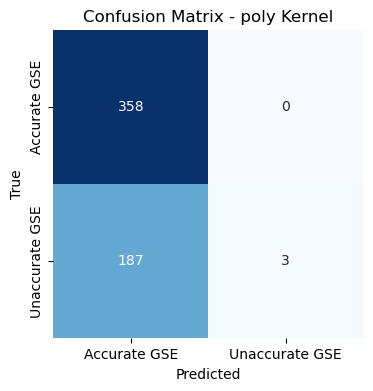

Evaluating rbf kernel...
rbf Best threshold (Youden): 0.353
rbf Kernel Accuracy: 0.6989
rbf Kernel Sensitivity: 0.9134
rbf Kernel Specificity: 0.2947


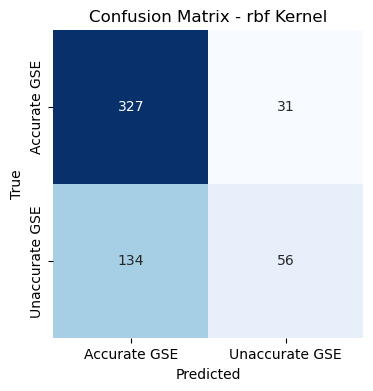

Evaluating sigmoid kernel...
sigmoid Best threshold (Youden): 0.353
sigmoid Kernel Accuracy: 0.6588
sigmoid Kernel Sensitivity: 1.0000
sigmoid Kernel Specificity: 0.0158


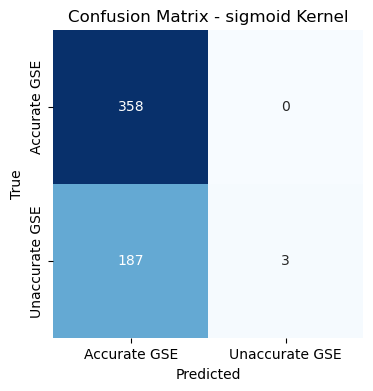

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

evaluation_results = {}

for kernel, best_estimator in best_estimators_per_kernel.items():
    print(f"Evaluating {kernel} kernel...")

    # Predict on the test set
    y_pred_proba = best_estimator.predict_proba(X_val)

    fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
    youden_j = tpr - fpr
    best_threshold_youden = thresholds[np.argmax(youden_j)]

    y_pred_proba_svm = best_estimator.predict_proba(X_test)
    y_pred_svm = (y_pred_proba_svm[:, 1] >= best_threshold_youden).astype(int)

    # Calculate the confusion matrix
    cm_svm = confusion_matrix(y_test, y_pred_svm)

    # Calculate accuracy, sensitivity, and specificity
    # Handle the case where a class might not be predicted
    tp_svm, fn_svm, fp_svm, tn_svm = cm_svm.ravel() if cm_svm.size == 4 else (0, 0, 0, 0) # Initialize if confusion matrix is not 2x2

    accuracy = (tp_svm + tn_svm) / (tp_svm + tn_svm + fp_svm + fn_svm) if (tp_svm + tn_svm + fp_svm + fn_svm) > 0 else 0
    sensitivity = tp_svm / (tp_svm + fn_svm) if (tp_svm + fn_svm) > 0 else 0
    specificity = tn_svm / (tn_svm + fp_svm) if (tn_svm + fp_svm) > 0 else 0
    f1_score = (2*tp_svm) / (2*tp_svm+fp_svm+fn_svm) if (2*tp_svm+fp_svm+fn_svm) > 0 else 0
    mcc = (tp_svm*tn_svm-fp_svm*fn_svm) / ((tp_svm+fp_svm)*(tp_svm+fn_svm)*(tn_svm+fp_svm)*(tn_svm+fn_svm))**0.5


    evaluation_results[kernel] = {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'confusion_matrix': cm_svm,
        'f1_score': f1_score,
        'mcc': mcc
    }

    # Print the results
    print(f"{kernel} Best threshold (Youden): {best_threshold_youden:.3f}")
    print(f'{kernel} Kernel Accuracy: {accuracy:.4f}')
    print(f'{kernel} Kernel Sensitivity: {sensitivity:.4f}')
    print(f'{kernel} Kernel Specificity: {specificity:.4f}')

    # Plot the confusion matrix
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Accurate GSE', 'Unaccurate GSE'], yticklabels=['Accurate GSE', 'Unaccurate GSE'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {kernel} Kernel')
    plt.show()

## **Step 5: XGBoost Classifier**

1. Train XGBoost with the training set.
2. Optimize hyperparameters.
3. Predict the test set.
4. Report Accuracy, sensitivity, and specificity.

In [10]:
!pip install xgboost

/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:00:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:00:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:00:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:00:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/pytho

Best hyperparameters found by RandomizedSearchCV for XGBoost:
{'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 0.05, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:00:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best threshold (Youden): 0.305
Optimized decision threshold: 0.30459439754486084
Optimized XGBoost Model Accuracy: 0.7080
Optimized XGBoost Model Sensitivity: 0.7067
Optimized XGBoost Model Specificity: 0.7105


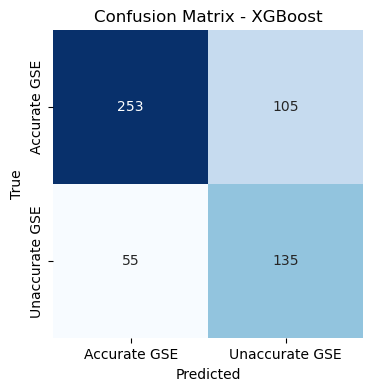

In [11]:
from xgboost import XGBClassifier

# Instantiate XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Set eval_metric to avoid warning

# Define the hyperparameter grid for RandomizedSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9, 11],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.001, 0.005, 0.01, 0.05, 0.1],
    'reg_lambda': [0, 0.001, 0.005, 0.01, 0.05, 0.1]
}

# Instantiate RandomizedSearchCV for XGBoost
random_search_xgb = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid_xgb, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)

# Fit the RandomizedSearchCV object to the training data
random_search_xgb.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters found by RandomizedSearchCV for XGBoost:")
print(random_search_xgb.best_params_)

# Train the XGBoost model with the best hyperparameters
xgb_optimized = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', **random_search_xgb.best_params_)
xgb_optimized.fit(X_train_val, y_train_val)

# Predict on the test set
y_val_proba = xgb_optimized.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
youden_j = tpr - fpr
best_threshold_youden = thresholds[np.argmax(youden_j)]
print(f"Best threshold (Youden): {best_threshold_youden:.3f}")

y_pred_xgb_proba = xgb_optimized.predict_proba(X_test)[:, -1]
y_pred_xgb = (y_pred_xgb_proba >= best_threshold_youden).astype(int)
print(f'Optimized decision threshold: {best_threshold_youden}')

# Calculate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Calculate accuracy, sensitivity, and specificity
tp_xgb, fn_xgb, fp_xgb, tn_xgb = cm_xgb.ravel()

accuracy_xgb = (tp_xgb + tn_xgb) / (tp_xgb + tn_xgb + fp_xgb + fn_xgb)
sensitivity_xgb = tp_xgb / (tp_xgb + fn_xgb)
specificity_xgb = tn_xgb / (tn_xgb + fp_xgb)
f1_score_xgb = (2*tp_xgb) / (2*tp_xgb+fp_xgb+fn_xgb)
mcc_xgb = (tp_xgb*tn_xgb-fp_xgb*fn_xgb) / ((tp_xgb+fp_xgb)*(tp_xgb+fn_xgb)*(tn_xgb+fp_xgb)*(tn_xgb+fn_xgb))**0.5

# Print the results
print(f'Optimized XGBoost Model Accuracy: {accuracy_xgb:.4f}')
print(f'Optimized XGBoost Model Sensitivity: {sensitivity_xgb:.4f}')
print(f'Optimized XGBoost Model Specificity: {specificity_xgb:.4f}')

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Accurate GSE', 'Unaccurate GSE'], yticklabels=['Accurate GSE', 'Unaccurate GSE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - XGBoost')
plt.show()

## **Step 6: Naive Bayes Classifier**

1. Train Naive Bayes with the training set.
2. Optimize hyperparameters.
3. Predict the test set.
4. Report Accuracy, sensitivity, and specificity.

Best hyperparameters found by GridSearchCV for Naive Bayes:
{'var_smoothing': 1e-09}
Best threshold (Youden): 0.196
Optimized Naive Bayes Model Accuracy: 0.6478
Optimized Naive Bayes Model Sensitivity: 0.8352
Optimized Naive Bayes Model Specificity: 0.2947


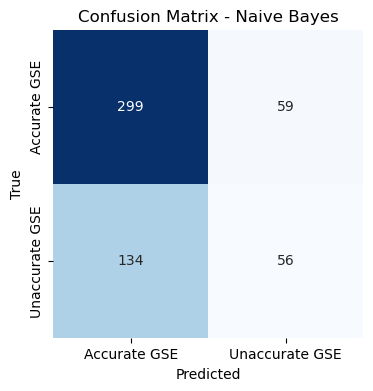

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate Gaussian Naive Bayes Classifier
nb_model = GaussianNB()

# Define the hyperparameter grid for GridSearchCV
# GaussianNB doesn't have many hyperparameters to tune.
# We can tune 'var_smoothing', which is a small value added to the variances for calculation stability.
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

# Instantiate GridSearchCV for Naive Bayes
grid_search_nb = GridSearchCV(estimator=nb_model, param_grid=param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search_nb.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters found by GridSearchCV for Naive Bayes:")
print(grid_search_nb.best_params_)

# Train the Naive Bayes model with the best hyperparameters
nb_optimized = GaussianNB(**grid_search_nb.best_params_)
nb_optimized.fit(X_train_val, y_train_val)

# Predict on the test set
y_val_proba = nb_optimized.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
youden_j = tpr - fpr
best_threshold_youden = thresholds[np.argmax(youden_j)]
print(f"Best threshold (Youden): {best_threshold_youden:.3f}")


# Predict on the test se
y_pred_nb_proba = nb_optimized.predict_proba(X_test)[:, 1]
y_pred_nb = (y_pred_nb_proba >= best_threshold_youden).astype(int)

# Calculate the confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Calculate accuracy, sensitivity, and specificity
tp_nb, fn_nb, fp_nb, tn_nb = cm_nb.ravel()

accuracy_nb = (tp_nb + tn_nb) / (tp_nb + tn_nb + fp_nb + fn_nb)
sensitivity_nb = tp_nb / (tp_nb + fn_nb)
specificity_nb = tn_nb / (tn_nb + fp_nb)
f1_score_nb = (2*tp_nb) / (2*tp_nb+fp_nb+fn_nb)
mcc_nb = (tp_nb*tn_nb-fp_nb*fn_nb) / ((tp_nb+fp_nb)*(tp_nb+fn_nb)*(tn_nb+fp_nb)*(tn_nb+fn_nb))**0.5

# Print the results
print(f'Optimized Naive Bayes Model Accuracy: {accuracy_nb:.4f}')
print(f'Optimized Naive Bayes Model Sensitivity: {sensitivity_nb:.4f}')
print(f'Optimized Naive Bayes Model Specificity: {specificity_nb:.4f}')

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Accurate GSE', 'Unaccurate GSE'], yticklabels=['Accurate GSE', 'Unaccurate GSE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

## **Step 7: Artificial Neural Network**

In [13]:
!pip install tensorflow
!pip install scikeras

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.metrics import AUC
from tensorflow.keras.regularizers import l2
import tensorflow as tf


scaler = StandardScaler()
X_train_val_s = scaler.fit_transform(X_train_val)
X_val_s         = scaler.transform(X_val)
X_test_s        = scaler.transform(X_test)

# Calculate class weights
class_weight_dict = {0: 1.0, 1: 1.0}

# Improved model
NN = Sequential([
        Input(shape=(X_train_val_s.shape[1],)),
        Dense(32, activation='relu',kernel_regularizer=l2(1e-3)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(16, activation='relu',kernel_regularizer=l2(1e-3)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

# More principled than class_weight alone for imbalanced data


def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1-y_true) * tf.math.log(1-y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_w = alpha * y_true + (1 - alpha) * (1 - y_true)
        return focal_w * tf.pow(1 - p_t, gamma) * bce
    return loss

# Optimizer with custom learning rate
optimizer = Adam(learning_rate=0.0005)

NN.compile(optimizer=optimizer, loss=focal_loss(gamma=2.0, alpha=0.75), metrics=['accuracy', AUC(name='auc')])

# Callbacks
early_stop = EarlyStopping(monitor='val_auc', patience=30,  #monitor changed to val_auc to also monitor threshold
                          restore_best_weights=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                             patience=15, min_lr=1e-7)


kcv_NN = KerasClassifier(
    model=NN,
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
  )

# Fit the KerasClassifier model to the training data
kcv_NN.fit(X_train_val_s, y_train_val,
           validation_data=(X_val_s, y_val))

# Predict on the test set
y_val_proba = kcv_NN.predict_proba(X_val_s)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
youden_j = tpr - fpr
best_threshold_youden = thresholds[np.argmax(youden_j)]
print(f"Best threshold (Youden): {best_threshold_youden:.3f}")

# Final evaluation on the HELD-OUT test set (never seen during training)
y_pred_NN_proba = kcv_NN.predict_proba(X_test_s)[:, 1]
y_pred_NN_binary = (y_pred_NN_proba >= best_threshold_youden).astype(int)

2026-06-10 07:00:19.613679: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-10 07:00:19.827791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/esteban_b/miniforge3/lib/python3.12/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
2026-06-10 07:00:25.985081: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-10 07:00:27.654610: E ext

Epoch 1/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5123 - auc: 0.5207 - loss: 0.2873 - val_accuracy: 0.5786 - val_auc: 0.5933 - val_loss: 0.1553 - learning_rate: 5.0000e-04
Epoch 2/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5163 - auc: 0.5404 - loss: 0.2624 - val_accuracy: 0.5626 - val_auc: 0.6145 - val_loss: 0.1485 - learning_rate: 5.0000e-04
Epoch 3/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5014 - auc: 0.5353 - loss: 0.2448 - val_accuracy: 0.5649 - val_auc: 0.6376 - val_loss: 0.1427 - learning_rate: 5.0000e-04
Epoch 4/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5368 - auc: 0.5926 - loss: 0.2084 - val_accuracy: 0.5581 - val_auc: 0.6503 - val_loss: 0.1401 - learning_rate: 5.0000e-04
Epoch 5/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5362 - auc: 0.5897 - loss: 0.1973 - val_accuracy: 0.5649 - val_auc: 0.6547 - val_loss: 0.1380 - learning_rate: 5.0000e-04
Epoch 6/1000
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accu

Optimized decision threshold: 0.5303410291671753
Optimized Neural Network Model Accuracy: 0.6861
Optimized Neural Network Model Sensitivity: 0.7039
Optimized Neural Network Model Specificity: 0.6526


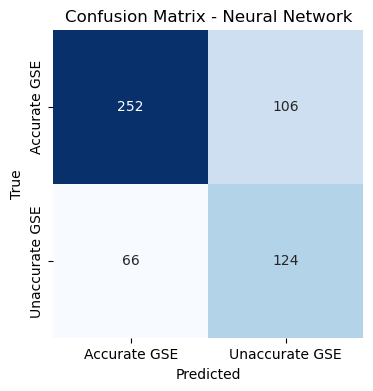

In [15]:
# Calculate the confusion matrix
cm_NN = confusion_matrix(y_test, y_pred_NN_binary)

# Calculate accuracy, sensitivity, and specificity
tp_NN, fn_NN, fp_NN, tn_NN = cm_NN.ravel()
accuracy_NN = (tp_NN + tn_NN) / (tp_NN + tn_NN + fp_NN + fn_NN)
sensitivity_NN = tp_NN / (tp_NN + fn_NN)
specificity_NN = tn_NN / (tn_NN + fp_NN)
f1_score_NN = (2*tp_NN) / (2*tp_NN+fp_NN+fn_NN)
mcc_NN = (tp_NN*tn_NN-fp_NN*fn_NN) / ((tp_NN+fp_NN)*(tp_NN+fn_NN)*(tn_NN+fp_NN)*(tn_NN+fn_NN))**0.5

# Print the results
print(f'Optimized decision threshold: {best_threshold_youden}')
print(f'Optimized Neural Network Model Accuracy: {accuracy_NN:.4f}')
print(f'Optimized Neural Network Model Sensitivity: {sensitivity_NN:.4f}')
print(f'Optimized Neural Network Model Specificity: {specificity_NN:.4f}')

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(cm_NN, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Accurate GSE', 'Unaccurate GSE'], yticklabels=['Accurate GSE', 'Unaccurate GSE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Neural Network')
plt.show()

**Average of best models**

In [16]:
y_prob_rf = RF_optimized.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_optimized.predict_proba(X_test)[:, 1]

Searching for optimal threshold...
Optimal threshold found: 0.38

Optimized Averaged Model Metrics (Threshold = 0.38):
Accuracy: 0.7628
Sensitivity: 0.8184
Specificity: 0.6579
F1 Score: 0.8184
MCC: 0.4763


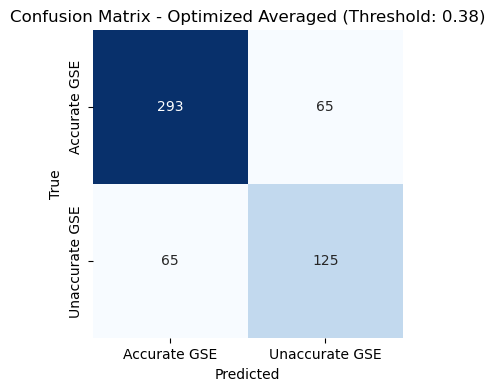

In [17]:
# Combine probability predictions from RF and NN
y_prob_avg = (y_prob_xgb + y_prob_rf) / 2

# Find the optimal threshold to maximize sum of sensitivity and specificity
thresholds = np.linspace(0, 1, 100)
best_threshold = 0.5
max_sum_metrics = 0

print("Searching for optimal threshold...")
for threshold in thresholds:
    y_pred_temp = (y_prob_avg > threshold).astype(int)
    cm_temp = confusion_matrix(y_test, y_pred_temp)

    # Ensure confusion matrix has all 4 elements (tp, fn, fp, tn)
    if cm_temp.size == 4:
        tn_temp, fp_temp, fn_temp, tp_temp = cm_temp.ravel()
    else:
        # Handle cases where one class might not be predicted
        # If y_pred_temp contains only 0s, tp and fn are 0. tn and fp depend on y_test.
        # If y_pred_temp contains only 1s, tn and fp are 0. tp and fn depend on y_test.
        if np.all(y_pred_temp == 0):
            tp_temp, fn_temp, fp_temp, tn_temp = 0, np.sum(y_test==1), np.sum(y_test==0), 0
        elif np.all(y_pred_temp == 1):
            tp_temp, fn_temp, fp_temp, tn_temp = np.sum(y_test==1), 0, 0, np.sum(y_test==0)
        else: # Fallback, should not happen if probabilities are diverse
            continue

    # Calculate sensitivity and specificity for the current threshold
    sensitivity_temp = tp_temp / (tp_temp + fn_temp) if (tp_temp + fn_temp) > 0 else 0
    specificity_temp = tn_temp / (tn_temp + fp_temp) if (tn_temp + fp_temp) > 0 else 0

    current_sum_metrics = sensitivity_temp + specificity_temp

    if current_sum_metrics > max_sum_metrics:
        max_sum_metrics = current_sum_metrics
        best_threshold = threshold

print(f"Optimal threshold found: {best_threshold:.2f}")

# Apply the optimal threshold to get final binary predictions
y_pred_optimized_avg = (y_prob_avg > best_threshold).astype(int)

# Calculate metrics with the optimized threshold
cm_optimized_avg = confusion_matrix(y_test, y_pred_optimized_avg)
tp_opt, fn_opt, fp_opt, tn_opt = cm_optimized_avg.ravel()

optimized_avg_accuracy = (tp_opt + tn_opt) / (tp_opt + tn_opt + fp_opt + fn_opt)
optimized_avg_sensitivity = tp_opt / (tp_opt + fn_opt)
optimized_avg_specificity = tn_opt / (tn_opt + fp_opt)
optimized_avg_f1_score = (2*tp_opt) / (2*tp_opt+fp_opt+fn_opt)
optimized_avg_mcc = (tp_opt*tn_opt-fp_opt*fn_opt) / ((tp_opt+fp_opt)*(tp_opt+fn_opt)*(tn_opt+fp_opt)*(tn_opt+fn_opt))**0.5

print(f'\nOptimized Averaged Model Metrics (Threshold = {best_threshold:.2f}):')
print(f'Accuracy: {optimized_avg_accuracy:.4f}')
print(f'Sensitivity: {optimized_avg_sensitivity:.4f}')
print(f'Specificity: {optimized_avg_specificity:.4f}')
print(f'F1 Score: {optimized_avg_f1_score:.4f}')
print(f'MCC: {optimized_avg_mcc:.4f}')

# You can also plot the confusion matrix for this optimized average model
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.heatmap(cm_optimized_avg, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Accurate GSE', 'Unaccurate GSE'], yticklabels=['Accurate GSE', 'Unaccurate GSE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Optimized Averaged (Threshold: {best_threshold:.2f})')
plt.show()

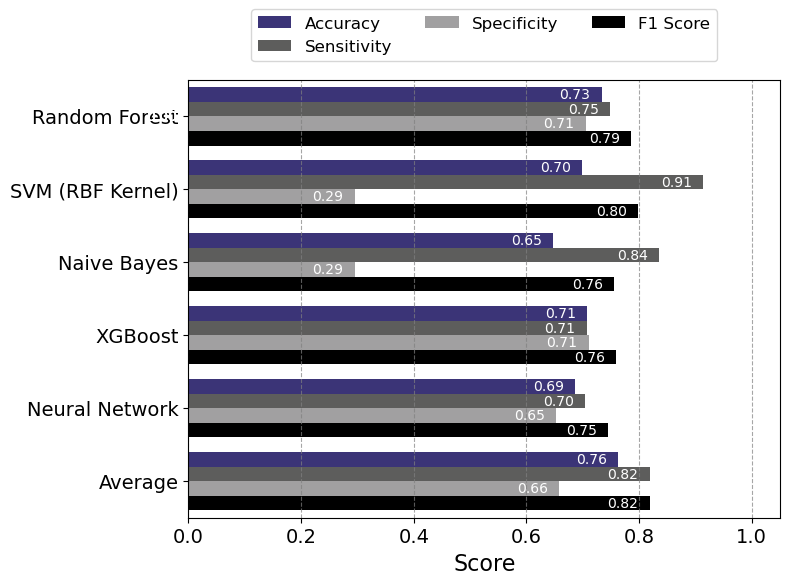

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the metrics into a single dictionary for easier processing
combined_metrics = {
    'Random Forest': {
        'Accuracy': rf_accuracy,
        'Sensitivity': rf_sensitivity,
        'Specificity': rf_specificity,
        'F1 Score': rf_f1_score
    },
    'SVM (RBF Kernel)': {
        'Accuracy': evaluation_results['rbf']['accuracy'],
        'Sensitivity': evaluation_results['rbf']['sensitivity'],
        'Specificity': evaluation_results['rbf']['specificity'],
        'F1 Score': evaluation_results['rbf']['f1_score']
    },
    'Naive Bayes': {
        'Accuracy': accuracy_nb,
        'Sensitivity': sensitivity_nb,
        'Specificity': specificity_nb,
        'F1 Score': f1_score_nb
    },
    'XGBoost': {
        'Accuracy': accuracy_xgb,
        'Sensitivity': sensitivity_xgb,
        'Specificity': specificity_xgb,
        'F1 Score': f1_score_xgb
    },
    'Neural Network': {
        'Accuracy': accuracy_NN,
        'Sensitivity': sensitivity_NN, # Corrected
        'Specificity': specificity_NN,  # Corrected
        'F1 Score': f1_score_NN
    },
    'Average': {
        'Accuracy': optimized_avg_accuracy,
        'Sensitivity': optimized_avg_sensitivity,
        'Specificity': optimized_avg_specificity,
        'F1 Score': optimized_avg_f1_score
    }
}

# Convert to DataFrame
df_metrics = pd.DataFrame.from_dict(combined_metrics, orient='index')
df_metrics.index.name = 'Model'

# Melt the DataFrame to long format
df_melted = df_metrics.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plotting
plt.figure(figsize=(8, 6))
ax = sns.barplot(y='Model', x='Score', hue='Metric', data=df_melted, palette=['#322982', '#5d5d5c', '#a1a0a1','#000000'])
ax.set_xlabel('Score', fontsize=16)
ax.set_ylabel('', fontsize=16)
ax.set_xlim(0, 1.05)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(title='', fontsize=12, loc='upper center', ncols = 3,bbox_to_anchor=(0,1.1,1,0.08))
plt.grid(True, axis='x', linestyle='--', color='gray', alpha=0.7)

# Add values inside the bars
for p in ax.patches:
    width = p.get_width()
    # Place text just inside the bar, aligned to the right
    plt.text(width - 0.02, # X-coordinate for the text, slightly inside the bar
             p.get_y() + p.get_height() / 2, # Y-coordinate for the text
             f'{width:.2f}', # Value to display
             ha='right', # Horizontal alignment to the right
             va='center', # Vertical alignment to the center
             color='white') # Text color for better visibility

plt.tight_layout()
plt.savefig('performance_ML.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('performance_ML.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.show()

/tmp/ipykernel_19611/1625749456.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y='Model', x='MCC Score', data=df_mcc, palette=['#322982', '#5d5d5c', '#a1a0a1', '#000000', '#625f92','#7F7F7F'])


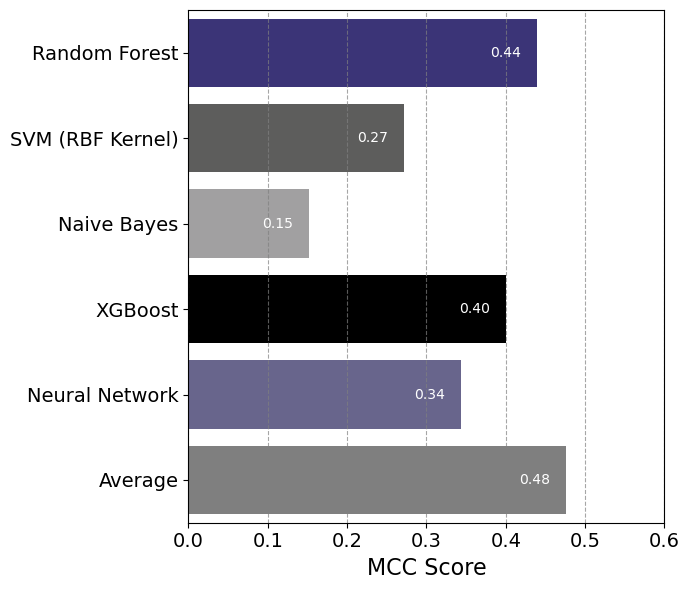

In [19]:
# Combine the MCC scores into a dictionary
mcc_scores = {
    'Random Forest': rf_mcc,
    'SVM (RBF Kernel)': evaluation_results['rbf']['mcc'],
    'Naive Bayes': mcc_nb,
    'XGBoost': mcc_xgb,
    'Neural Network': mcc_NN,
    'Average': optimized_avg_mcc
}

# Convert to DataFrame
df_mcc = pd.DataFrame(list(mcc_scores.items()), columns=['Model', 'MCC Score'])

# Plotting
plt.figure(figsize=(7, 6))
ax = sns.barplot(y='Model', x='MCC Score', data=df_mcc, palette=['#322982', '#5d5d5c', '#a1a0a1', '#000000', '#625f92','#7F7F7F'])
ax.set_xlabel('MCC Score', fontsize=16)
ax.set_ylabel('', fontsize=16)
ax.set_xlim(0, 0.6)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.grid(True, axis='x', linestyle='--', color='gray', alpha=0.7)

# Add values inside the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width - 0.02,
             p.get_y() + p.get_height() / 2,
             f'{width:.2f}',
             ha='right',
             va='center',
             color='white')

plt.tight_layout()
plt.savefig('mcc_scores_ML.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('mcc_scores_ML.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.show()

ROC-AUC scores + plots

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC-AUC scores for each model

y_prob_rf = RF_optimized.predict_proba(X_test)[:, 1]
y_prob_svm = best_estimators_per_kernel['rbf'].predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_optimized.predict_proba(X_test)[:, 1]
y_prob_nb = nb_optimized.predict_proba(X_test)[:, 1]
y_prob_nn = kcv_NN.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
auc_nb = roc_auc_score(y_test, y_prob_nb)
auc_nn = roc_auc_score(y_test, y_prob_nn)


auc_scores = {
    'Random Forest': auc_rf,
    'SVM (RBF Kernel)': auc_svm,
    'Naive Bayes': auc_nb,
    'XGBoost': auc_xgb,
    'Neural Network': auc_nn
}

auc_scores

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


{'Random Forest': 0.7770361658335783,
 'SVM (RBF Kernel)': 0.7380255807115554,
 'Naive Bayes': 0.5209203175536607,
 'XGBoost': 0.7732284622169949,
 'Neural Network': 0.5244119376653924}

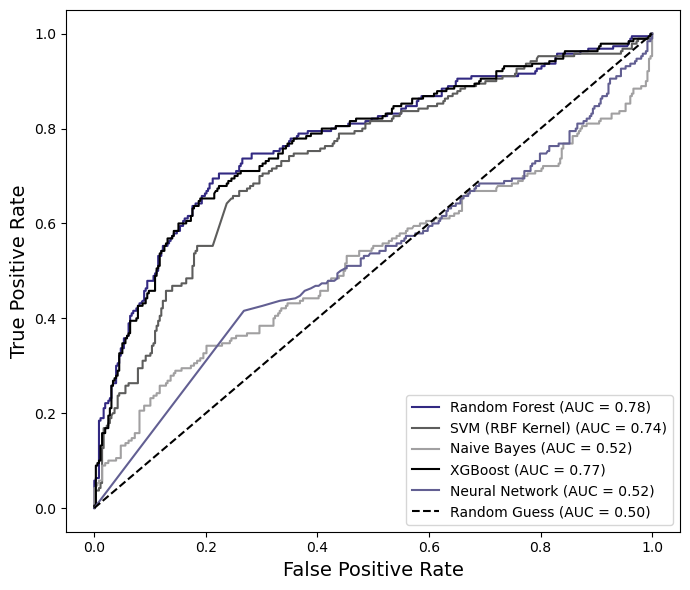

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='#322982')

# SVM (RBF Kernel)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (RBF Kernel) (AUC = {auc_svm:.2f})', color='#5d5d5c')

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.2f})', color='#a1a0a1')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})', color='#000000')

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})', color='#625f92')

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()

# Save the plot
plt.savefig('roc_auc_curve.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('roc_auc_curve.pdf', format='pdf', dpi=500, bbox_inches='tight')

plt.show()

## **Step 8: *k*-fold cross validation**

In [22]:
from sklearn.model_selection import cross_val_score


scores_rf = cross_val_score(RF_optimized, X, y, cv = 10)
scores_svm = cross_val_score(best_estimators_per_kernel['rbf'], X, y, cv = 10)
scores_xgb = cross_val_score(xgb_optimized, X, y, cv = 10)
scores_nb = cross_val_score(nb_optimized, X, y, cv = 10)


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler # Import StandardScaler for NN cross-validation
import numpy as np # Ensure numpy is available for class_weight

# Manual cross-validation
def create_model(input_dim):
    model = Sequential([
         Input(shape=(input_dim,)),
        Dense(32, activation='relu',kernel_regularizer=l2(1e-3)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(16, activation='relu',kernel_regularizer=l2(1e-3)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])
    return model

# Perform manual K-fold cross validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_NN = []

# Initialize a scaler for the Neural Network, as it expects scaled data.
# The scaler will be fitted for each fold to avoid data leakage.
scaler_nn_cv = StandardScaler()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"Fold {fold + 1}/10")

    # Split data using .iloc for correct row selection
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Scale data for the Neural Network within each fold
    X_train_fold_scaled = scaler_nn_cv.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler_nn_cv.transform(X_val_fold)

    # Calculate class weights for this fold
    class_weights_fold = compute_class_weight('balanced',
                                            classes=np.unique(y_train_fold),
                                            y=y_train_fold)
    class_weight_dict_fold = {0: class_weights_fold[0], 1: class_weights_fold[1]}

    # Create and train model
    model = create_model(X_train_fold_scaled.shape[1]) # Pass input_dim

    history = model.fit(
        X_train_fold_scaled, y_train_fold,
        epochs=1000,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        class_weight=class_weight_dict_fold,
        validation_data=(X_val_fold_scaled, y_val_fold),
        verbose=0
    )

    # Evaluate
    y_pred = (model.predict(X_val_fold_scaled) > best_threshold_youden).astype(int)
    accuracy = accuracy_score(y_val_fold, y_pred)
    scores_NN.append(accuracy)
    print(f"NN Fold {fold + 1} Accuracy: {accuracy:.4f}")

/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:03:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:03:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:03:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:03:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/esteban_b/miniforge3/lib/pytho

Fold 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
NN Fold 1 Accuracy: 0.6168
Fold 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
NN Fold 2 Accuracy: 0.6387
Fold 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
NN Fold 3 Accuracy: 0.7336
Fold 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
NN Fold 4 Accuracy: 0.6387
Fold 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
NN Fold 5 Accuracy: 0.5401
Fold 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
NN Fold 6 Accuracy: 0.6569
Fold 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
NN Fold 7 Accuracy: 0.5693
Fold 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
NN Fold 8 Accuracy: 0.5912
Fold 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
NN Fold 9 Accuracy: 0.5912
Fold 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
NN Fold 10 Accuracy: 0.5401


/tmp/ipykernel_19611/1048111199.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y='Model', x='Accuracy', data=cv_results_melted, inner=None, palette=['#322982', '#5d5d5c', '#a1a0a1', '#000000', '#625f92'], order=model_order, ax=ax)


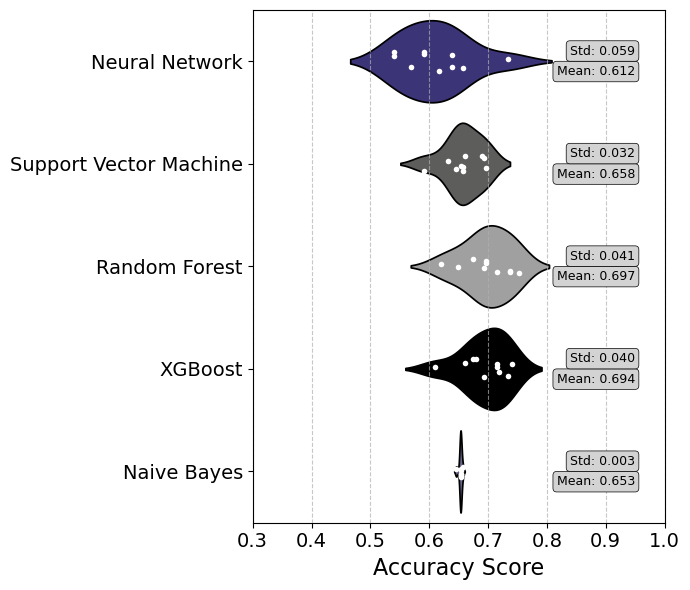

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame from the cross-validation scores
cv_results = pd.DataFrame({
    'Random Forest': scores_rf,
    'Support Vector Machine': scores_svm,
    'XGBoost': scores_xgb,
    'Naive Bayes': scores_nb,
    'Neural Network': scores_NN
})

# Melt the DataFrame to a long format for seaborn plotting
cv_results_melted = cv_results.melt(var_name='Model', value_name='Accuracy')

# Define the order for the x-axis
model_order = ["Neural Network", "Support Vector Machine", "Random Forest", "XGBoost", "Naive Bayes"]

# Create the figure and axes for the plot
plt.figure(figsize=(7, 6))
ax = plt.gca()

# Create the violin plot
sns.violinplot(y='Model', x='Accuracy', data=cv_results_melted, inner=None, palette=['#322982', '#5d5d5c', '#a1a0a1', '#000000', '#625f92'], order=model_order, ax=ax)

# Overlay the jitter plot (stripplot) for individual data points
sns.stripplot(y='Model', x='Accuracy', data=cv_results_melted, jitter=True, color='white', size=4, order=model_order, ax=ax)

# Calculate and add average accuracy and standard deviation as text boxes with rounded borders
for i, model_name in enumerate(model_order):
    model_scores = cv_results_melted[cv_results_melted['Model'] == model_name]['Accuracy']
    mean_accuracy = model_scores.mean()
    std_accuracy = model_scores.std()

    # Position the text slightly to the right of the plot origin
    # Use ax.annotate for text boxes with styling
    ax.annotate(f'Mean: {mean_accuracy:.3f}',
                xy=(0.95, i + 0.1),
                xycoords='data',
                ha='right', va='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', ec='black', lw=0.5))
    ax.annotate(f'Std: {std_accuracy:.3f}',
                xy=(0.95, i - 0.1),
                xycoords='data',
                ha='right', va='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightgray', ec='black', lw=0.5))

ax.set_xlabel('Accuracy Score', fontsize=16)
ax.set_ylabel('', fontsize=16)
ax.set_xlim(0.3, 1.0) # Adjusted x-axis limit for text boxes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('cv_accuracy_distribution.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('cv_accuracy_distribution.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.show()